In [116]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Bidirectional,
    BatchNormalization, Input
)
from tensorflow.keras.layers import Layer
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [87]:
#Leitura dos dados e criação das features derivadas

dados = pd.read_parquet("drive/MyDrive/ProjetoFinal/petr4.parquet")
dados["time_date"] = pd.to_datetime(dados["time"], unit='s')
dados["return_1"] = dados["close"].pct_change()
dados["return_5"] = dados["close"].pct_change(5)
dados["return_10"] = dados["close"].pct_change(10)
dados["volatility"] = dados["return_1"].rolling(20).std()
dados["hour"] = dados["time_date"].dt.hour
dados["hour_sin"] = np.sin(2*np.pi*dados["hour"]/24)
dados["hour_cos"] = np.cos(2*np.pi*dados["hour"]/24)
dados["ema9"] = dados["close"].ewm(span=9).mean()
dados["ema21"] = dados["close"].ewm(span=21).mean()

delta = dados["close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
dados["rsi"] = 100 - (100 / (1 + rs))

dados = dados.dropna()
dados

,time,open,high,low,close,tick_volume,spread,real_volume,time_date,return_1,return_5,return_10,volatility,hour,hour_sin,hour_cos,ema9,ema21,rsi
20,1609772400,11.17,11.20,11.15,11.19,2742,1,1153400,2021-01-04 15:00:00,0.001791,-0.000893,-0.009735,0.003754,15,-0.707107,-0.707107,11.195210,11.219015,31.578947
21,1609773300,11.20,11.24,11.18,11.24,3641,1,2106000,2021-01-04 15:15:00,0.004468,0.003571,0.002676,0.003869,15,-0.707107,-0.707107,11.204235,11.221190,36.585366
22,1609774200,11.24,11.24,11.22,11.23,2012,1,1151700,2021-01-04 15:30:00,-0.000890,0.005372,0.000891,0.003164,15,-0.707107,-0.707107,11.209419,11.222092,37.500000
23,1609775100,11.22,11.25,11.22,11.24,2229,1,844500,2021-01-04 15:45:00,0.000890,0.008977,0.003571,0.003116,15,-0.707107,-0.707107,11.215564,11.223904,35.897436
24,1609776000,11.24,11.26,11.22,11.24,2465,1,1039200,2021-01-04 16:00:00,0.000000,0.006267,0.001783,0.002852,16,-0.866025,-0.500000,11.220470,11.225516,41.176471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21306,1698768000,34.76,34.79,34.65,34.67,1828,1,810300,2023-10-31 16:00:00,-0.002589,-0.003449,-0.002876,0.002219,16,-0.866025,-0.500000,34.718845,34.780147,39.473684
21307,1698768900,34.67,34.69,34.57,34.68,2118,1,1483100,2023-10-31 16:15:00,0.000288,-0.001152,-0.003162,0.001714,16,-0.866025,-0.500000,34.711076,34.771043,38.666667
21308,1698769800,34.68,34.75,34.63,34.73,2665,1,1649300,2023-10-31 16:30:00,0.001442,0.002598,0.001731,0.001738,16,-0.866025,-0.500000,34.714861,34.767312,47.222222
21309,1698770700,34.73,34.79,34.68,34.73,1723,1,1493800,2023-10-31 16:45:00,0.000000,0.001442,0.001153,0.001722,16,-0.866025,-0.500000,34.717889,34.763920,48.571429


In [89]:
#Criação da lista de features

features = [
    "close",
    "real_volume",
    "return_1",
    "ema9",
    "ema21",
    "volatility",
    "hour_sin",
    "hour_cos"
]

data = dados[features].values

In [91]:
#Normalização dos dados

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [94]:
# Definição das variáveis de janela de dias usadas na predição, como são utilizados intervalos de 15 minutos para os dados, então cada dia completo de pregão correspodem as 28 candles.
# A cada conjunto de 5 dias de entrada é realizada a predição de 1 dia completo.

candles_day = 28
input_window = candles_day * 5
output_window = candles_day
test_size = candles_day * 30

# Criação dos conjuntos de treino e de teste

x_train = []
y_train = []

for i in range(input_window, len(scaled_data)-test_size-output_window):
    x_train.append(scaled_data[i-input_window:i])
    y_train.append(scaled_data[i:i+output_window,0])

x_test = []
y_test = []

for i in range(len(scaled_data)-test_size, len(scaled_data)-output_window):
    x_test.append(scaled_data[i-input_window:i])
    y_test.append(scaled_data[i:i+output_window,0])

x_train = np.array(x_train)
y_train = np.array(y_train)

x_test = np.array(x_test)
y_test = np.array(y_test)


In [95]:
#Definição do modelo de LSTM em múltiplas camadas

def get_model(input_window, n_features, output_window):

    model = Sequential()

    model.add(Input(shape=(input_window,n_features)))

    model.add(Bidirectional(LSTM(128, return_sequences=True)))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    model.add(Bidirectional(LSTM(64, return_sequences=False)))
    model.add(Dropout(0.3))

    model.add(Dense(64, activation="relu"))
    model.add(Dropout(0.2))

    model.add(Dense(output_window))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=[
            tf.keras.metrics.RootMeanSquaredError(),
            tf.keras.metrics.MeanAbsoluteError()
        ]
    )

    return model

In [96]:
#Treinando o modelo

model = get_model(input_window, len(features), output_window)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_test,y_test),
    epochs=60,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/60
317/317 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - loss: 0.0190 - mean_absolute_error: 0.0863 - root_mean_squared_error: 0.1378 - val_loss: 0.0034 - val_mean_absolute_error: 0.0466 - val_root_mean_squared_error: 0.0581
Epoch 2/60
317/317 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 0.0051 - mean_absolute_error: 0.0495 - root_mean_squared_error: 0.0713 - val_loss: 0.0011 - val_mean_absolute_error: 0.0253 - val_root_mean_squared_error: 0.0327
Epoch 3/60
317/317 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.0032 - mean_absolute_error: 0.0395 - root_mean_squared_error: 0.0568 - val_loss: 0.0076 - val_mean_absolute_error: 0.0836 - val_root_mean_squared_error: 0.0873
Epoch 4/60
317/317 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.0025 - mean_absolute_error: 0.0352 - root_mean_squared_error: 0.0499 - val_loss: 0.0028 - val_mean_absolute_error: 0.0448 - val_root_mean_squared_error: 0.0528
Epoch 5/60
317/317 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.0022 - mean_absolute_error: 0.0333 - roo

In [102]:
#Função para reverter a normalização dos dados e recuperar os dados conjunto de origem.

def inverse_close_scaling(data, scaler):

    close_min = scaler.data_min_[0]
    close_max = scaler.data_max_[0]

    return data * (close_max - close_min) + close_min

In [103]:
#Rodando o modelo no conjunto de teste.

predictions = model.predict(x_test)
predictions_rescaled = inverse_close_scaling(predictions, scaler)
y_test_rescaled = inverse_close_scaling(y_test, scaler)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


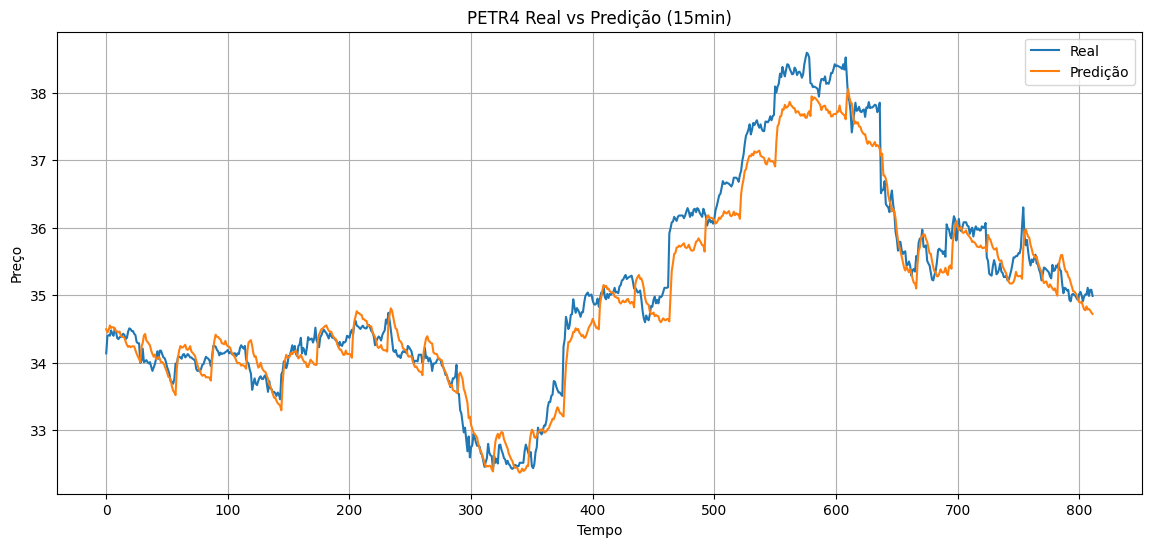

In [108]:
#Gráfico de comparação dos dados reais e os valores de predição, cosidernado somente o primeiro candle previsto para cada conjunto de entrada.

pred_series = predictions_rescaled[:,0]
real_series = y_test_rescaled[:,0]

plt.figure(figsize=(14,6))

plt.plot(real_series, label="Real")
plt.plot(pred_series, label="Predição")

plt.title("PETR4 Real vs Predição (15min)")
plt.xlabel("Tempo")
plt.ylabel("Preço")

plt.legend()
plt.grid()

plt.show()

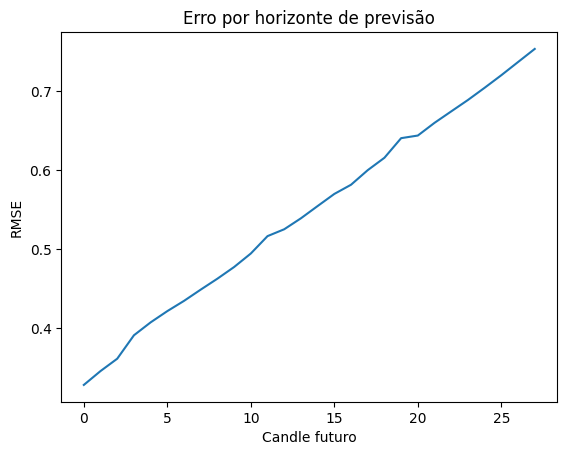

In [113]:
#Gráfico mostrando a evolução dos erros por horizonte de previsão, ou seja, ao longo do 28 candels, quanto mais para o futuro pior a qualidade da informação.

errors = []

for i in range(28):

    e = np.sqrt(mean_squared_error(
        y_test_rescaled[:,i],
        predictions_rescaled[:,i]
    ))

    errors.append(e)

plt.plot(errors)

plt.title("Erro por horizonte de previsão")
plt.xlabel("Candle futuro")
plt.ylabel("RMSE")

plt.show()

In [119]:
#Principais métricas para avaliação da eficácia do modelo.

mae = mean_absolute_error(real_series, pred_series)
print("MAE:", mae)

rmse = np.sqrt(mean_squared_error(real_series, pred_series))
print("RMSE:", rmse)

mape = np.mean(np.abs((real_series - pred_series) / real_series))
print("MAPE:", mape)

real = y_test_rescaled[:,0]
pred = predictions_rescaled[:,0]
real_direction = np.sign(np.diff(real))
pred_direction = np.sign(np.diff(pred))
accuracy = np.mean(real_direction == pred_direction)
print("Acurácia direcional:", accuracy)

ic = np.corrcoef(pred_series[:-1], real_series[1:])[0,1]
print("Coeficiente de Informação:", ic)

MAE: 0.25929450937386245
RMSE: 0.3279364789087476
MAPE: 0.007280851957994386
Acurácia direcional: 0.4882860665844636
Coeficiente de Informação: 0.9796260640024999
